# RAPID-MFA-4: The stock driven model using an outflow generation curve instead of a survival curve

## Descriptions
This variant of the stock driven model utilizes an _outflow  generation curve_ instead of a _survival curve_ as an input to the model.

- Use the _survival curve_ model to:
    1.  Answer the question "how long does an inflow cohort last in the stocks?"
    2. Analyze the composition of the stocks with the _cohorts survival matrix_.

- Use the _outflow generation curve_ model to:
    1. Answer the question "when does an inflow cohort become an outflow?"
    2. Analyze the composition of the outflows with the _cohorts outflow matrix_.

This model takes two inputs:
- A _stocks_ time series (of materials, products, service units, etc.)
- An _outflow generation curve_ describing the fraction of an inflow cohort that leaves the stocks and becomes part of the outflow at any given time.

It produces two main model outputs:
- The _inflows_ time series
- The _outflows_ time series

And two auxiliary model outputs:
- The _cohorts outflow matrix_ table
- The _stock changes_ (net addition to stock) time series

using the stock driven model outflow generation variant equations:
$$
\begin{align}
\textcolor{#8E795E}{\text{stock\_changes}(t)} &= \textcolor{#DC322F}{\text{stocks}(t)} - \textcolor{#DC322F}{\text{stocks}(t-1)}
\\
\textcolor{#20B2AA}{\text{inflows}(t)} &= \frac{\textcolor{#8E795E}{\text{stock\_changes}(t)} + \sum_{c=t_0}^{t-1} [\textcolor{#20B2AA}{\text{inflows}(c)} \times \textcolor{#9370DB}{\text{outflow\_generation\_curve}(t-1-c)}]}{1 - \textcolor{#9370DB}{\text{outflow\_generation\_curve}(0)}}
\\
\textcolor{#D19F37}{\text{outflows}(t)} &= \textcolor{#2A8596}{\text{inflows}(t)} - \textcolor{#8E795E}{\text{stock\_changes}(t)}
\end{align}
$$

### Notes
1. The _outflow generation curve_ of this model is derived from the _survival curve_, not from a SciPy function, to ensure that the resulting model outputs are virtually identical to those calculated with the model using the _survival curve_. See `RAPID-MFA-5: A library of survival curves` for further explanation.

2. The outflow generation curve of this example (normal distribution) was chosen to exemplify a case in which there is already some outflow (non-surviving stock) during the year in which the inflow occured. E.g. $outflow\_generation\_curve(age = 0) > 0$.

### The exogenous input variables used in this example
__Stocks:__ mock stocks values for years 1950-2019, in kg.

__Survival curve__ (from which the __outflow generation curve__ is derived): mock values. Normal distribution, $mean=30$, $SD=8.5$.

### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: The example in this code derives the __outflow generation curve__ from `RAPID-MFA-2: The stock driven model`'s __survival curve__, and the input __stocks__ data are identical. This is in order to show the equivalency of the models with __survival curves__ and __outflow generation curves__. The model structure is identical for ease of comparison.

- `RAPID-MFA-3: The flow driven model with an outflow generation curve`: is the flow-driven version of this code, and uses the same __outflow generation curve__ and __stocks__ from here to show that the models are the reverse operations of each other.

- `RAPID-MFA-5: A library of survival curves`: describes the relations between the __survival curve__ and __outflow generation curve__ and the technical reason for not using SciPy to generate the __outflow generation curve__.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [1]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns

## 2. Define example input data

In [2]:
# %% 2. Define example input data

# stocks data
input_data = pd.Series([1299.6975823,       2699.2088439999998, 3898.5122223,       4897.5146912,
                        5596.1111347999995, 7593.7676341999995, 9790.3254385,       12085.3702772,
                        14878.236956,       17868.1931554,      19254.6465997,      20536.1767666, 
                        22511.102249000003, 24677.600006200002, 27633.2189704,      29075.6457275, 
                        32001.0827125,      35205.8857545,      37885.8588263,      40636.0181198, 
                        41951.2947246,      44425.3763232,      47152.122083999995, 50024.97634079999, 
                        52937.21044549999,  55882.04176919999,  58952.77810709999,  61643.12697669999, 
                        64746.97994249999,  67859.00552129999,  70274.67869049999,  73289.90071599999, 
                        76601.6953655,      80407.8897283,      84207.3297966,      87999.6228713, 
                        91885.10090430001,  96064.68824460001,  100539.808329,      104712.3261015, 
                        108784.1202204,     112757.07243968,    116832.8291535,     122312.42061113, 
                        125997.28886605,    129087.59914197,    132282.91175889,    135482.23008601, 
                        138683.84854315,    141885.3850872,     145183.804137639,   148775.47728947402, 
                        152056.47224253102, 155322.363692951,   158968.47456797402, 161990.35422655602, 
                        164983.39759476003, 167943.37824593892, 171066.4844396428,  174749.45930044842, 
                        176390.45907074612, 177987.76127631642, 179540.96353597206, 180950.77883671026, 
                        182418.98656639198, 185248.20469443387, 186242.99278443994, 186608.17355946472, 
                        187049.45240187363, 188373.1468656902], 
                       name = 'stocks', 
                       index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 
                                1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 
                                1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 
                                1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 
                                1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 
                                2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                                2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])  # mock values

# Paramters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 30
std_dev = 8.5 

# create the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev) 

# Define the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.
outflow_generation_curve = list(abs(np.diff(survival_curve, prepend=1)))  # prepend 1 is needed to calculate the outflow generated during cohort age 0

## 3. Set up the MFA system

In [3]:
# %% 3. Set up the MFA system
units = {'time_interval': 'year', 
         'flows':         'kg/year', 
         'stocks':        'kg'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

time_interval = 1 # Interval between timeframes, often 1 year or 1 month etc.

cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required

mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

mfa_system['stocks'] = input_data
mfa_system['stocks']

1950      1299.697582
1951      2699.208844
1952      3898.512222
1953      4897.514691
1954      5596.111135
            ...      
2015    185248.204694
2016    186242.992784
2017    186608.173559
2018    187049.452402
2019    188373.146866
Name: stocks, Length: 70, dtype: float64

## 4. Create the outflow generation curves matrix

In this basic example, all inflow cohorts have the same outflow generation curve so the outflow generation curve is shifted down the diagonal of the matrix, i.e. a [Toeplitz matrix](https://en.wikipedia.org/wiki/Toeplitz_matrix).

In [4]:
# %% 4. Create outflow generation curves matrix
# create outflow generation curves matrix filled with zeros
outflow_generation_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the outflow generation curve and fill the next column of the outflow generation curves matrix with the shifted outflow generation curve from the diagonal downwards.
    outflow_generation_curves_matrix.loc[cohort: , cohort] = outflow_generation_curve[0 : cohort_stop - cohort]

outflow_generation_curves_matrix

,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
1950,0.000208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1951,0.000114,0.000208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1952,0.000171,0.000114,0.000208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1953,0.000252,0.000171,0.000114,0.000208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1954,0.000366,0.000252,0.000171,0.000114,0.000208,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,0.000013,0.000020,0.000032,0.000049,0.000076,0.000114,0.000171,0.000252,0.000366,0.000524,...,0.000524,0.000366,0.000252,0.000171,0.000114,0.000208,0.000000,0.000000,0.000000,0.000000
2016,0.000008,0.000013,0.000020,0.000032,0.000049,0.000076,0.000114,0.000171,0.000252,0.000366,...,0.000740,0.000524,0.000366,0.000252,0.000171,0.000114,0.000208,0.000000,0.000000,0.000000
2017,0.000005,0.000008,0.000013,0.000020,0.000032,0.000049,0.000076,0.000114,0.000171,0.000252,...,0.001031,0.000740,0.000524,0.000366,0.000252,0.000171,0.000114,0.000208,0.000000,0.000000
2018,0.000003,0.000005,0.000008,0.000013,0.000020,0.000032,0.000049,0.000076,0.000114,0.000171,...,0.001417,0.001031,0.000740,0.000524,0.000366,0.000252,0.000171,0.000114,0.000208,0.000000


# %% 5.1. Calculate the stock changes
$$\textcolor{#8E795E}{\text{stock\_changes}(t)} = \textcolor{#DC322F}{\text{stocks}(t)} - \textcolor{#DC322F}{\text{stocks}(t-1)}$$
prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 

In [5]:
# %%% 5.1 calculate stock changes (net change to stock)
# stock_changes is the difference between two timeframes.
# prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
mfa_system["stock_changes"]

1950    1299.697582
1951    1399.511262
1952    1199.303378
1953     999.002469
1954     698.596444
           ...     
2015    2829.218128
2016     994.788090
2017     365.180775
2018     441.278842
2019    1323.694464
Name: stock_changes, Length: 70, dtype: float64

## 5.2. Create cohorts outflows matrix

Each column of the cohorts' outflows matrix describes the portion from the inflow cohort that becomes an outflow as time goes by.

Each row of the cohorts' outflows matrix describes the amount of outflow from each past and present inflow cohort, i.e. the composition of the outflows.

In the stock-driven model with the outflow generation curve, each column of this matrix is created iteratively with the inflow calculated with the following equation, and using the inflows calculated in the previous iterations:

$$
\textcolor{#20B2AA}{\text{inflows}(t)} = \frac{\textcolor{#8E795E}{\text{stock\_changes}(t)} + \sum_{c=t_0}^{t-1} [\textcolor{#20B2AA}{\text{inflows}(c)} \times \textcolor{#9370DB}{\text{outflow\_generation\_curve}(t-1-c)}]}{1 - \textcolor{#9370DB}{\text{outflow\_generation\_curve}(0)}}
$$

The denominator $1 - \textcolor{#9370DB}{\text{outflow\_generation\_curve}(0)}$ deals with any throughput of inflows that become outflows in the same year. In survival curves like the Weibull in which the value of $\text{outflow\_generation\_curve}(0) = 0$, there are no throughputs.

[Text(0.5, 23.52222222222222, "Cohorts (each inflow's own outflows over time)"),
 Text(50.722222222222214, 0.5, 'Timeframe (how much of each inflow goes out of stock)')]

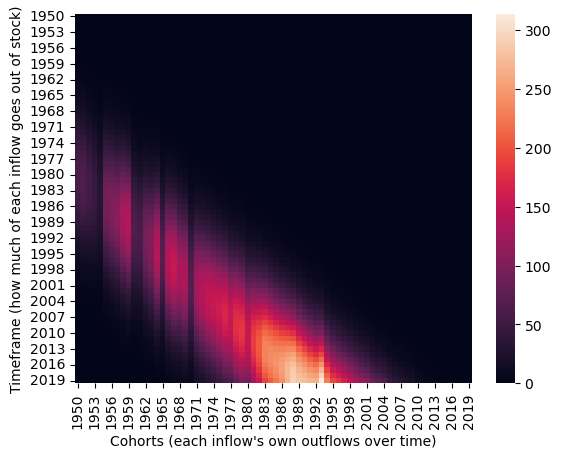

In [6]:
# %% 5.2. Create cohorts outflows matrix

# initialize the cohorts_outflows_matrix filled with zeros
cohorts_outflows_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stock_changes'] + cohorts_outflows_matrix.loc[cohort, : cohort - 1].sum()
        ) / (1 - outflow_generation_curves_matrix.loc[cohort, cohort])
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_outflows_matrix.loc[:, cohort] = outflow_generation_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']

# and visualize the cohorts_outflows_matrix matrix with a heatmap
sns.heatmap(cohorts_outflows_matrix, annot=False).set(xlabel ="Cohorts (each inflow's own outflows over time)", ylabel = "Timeframe (how much of each inflow goes out of stock)")

## 6. Calculate the MFA system
### 6.1 Calculate outflows
Using mass balance
$$
\textcolor{#D19F37}{\text{outflows}(t)} = \textcolor{#2A8596}{\text{inflows}(t)} - \textcolor{#8E795E}{\text{stock\_changes}(t)}
$$


In [7]:
# %% 6. Calculate the MFA system
# %%% 6.1 Calculate outflows using mass balance
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]

It's also possible to calculate total outflows as the sum of the outflow from each cohort, which is the sum of cohorts outflows matrix row by row.
$$
\textcolor{#D19F37}{\text{outflows}(t)} = \sum_{c=0}^{t}{ [ \textcolor{#2A8596}{\text{inflows}(c)} \times \textcolor{#722299}{\text{outflow\_generation\_curve}(t-c)}  ] } 
$$

In [8]:
# the total outflows are the sum of the outflows from each cohort, which is the sum of cohorts outflows matrix row by row.
mfa_system["outflows_alt"] = cohorts_outflows_matrix.sum(axis='columns')
mfa_system[["outflows","outflows_alt"]]

,outflows,outflows_alt
1950,0.270708,0.270708
1951,0.440345,0.440345
1952,0.632352,0.632352
1953,0.912145,0.912145
1954,1.293076,1.293076
...,...,...
2015,4871.299951,4871.299951
2016,5006.400993,5006.400993
2017,5136.565778,5136.565778
2018,5260.897208,5260.897208


## 7. View the full MFA system

<Axes: ylabel='kg/year'>

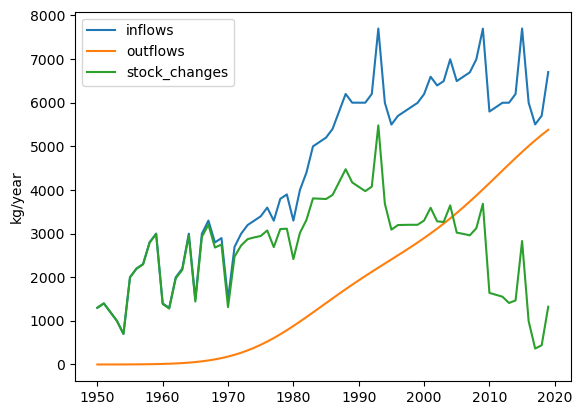

In [9]:
# %% 7. View the full MFA system
# plot flows
mfa_system[["inflows", "outflows", "stock_changes"]].plot(ylabel=units['flows'])

<Axes: ylabel='kg/year'>

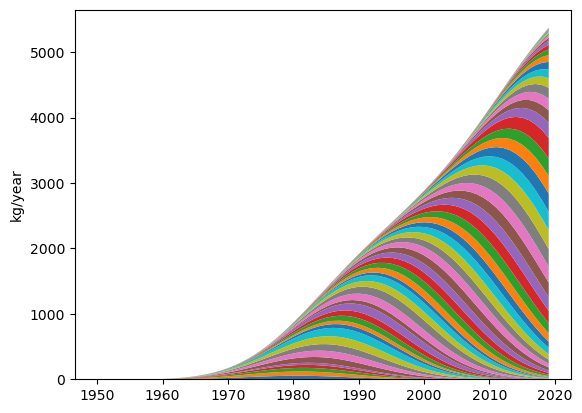

In [10]:
# plot outflows composition by cohorts
cohorts_outflows_matrix.plot(kind="area", stacked=True, legend = False, lw=0, ylabel=units['flows'])

<Axes: ylabel='kg'>

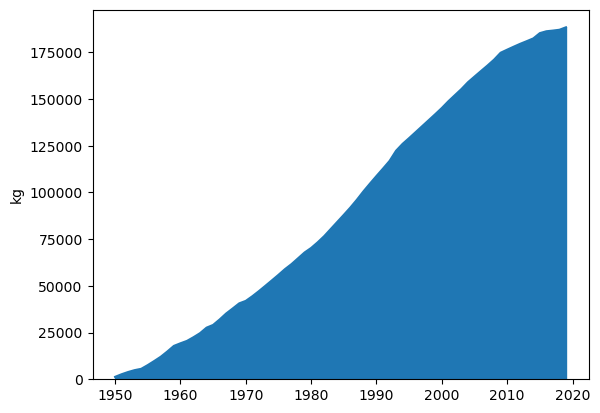

In [11]:
# plot stocks
mfa_system["stocks"].plot(kind="area", stacked=True, ylabel=units['stocks'])